## Diminos Case Study

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns


In [17]:
df = pd.read_csv("./diminos_data.csv")

In [18]:
df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [19]:
df.shape

(15000, 3)

In [20]:
df.columns

Index(['order_id', 'order_placed_at', 'order_delivered_at'], dtype='object')

In [21]:
# checing datatype of both date columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            15000 non-null  int64 
 1   order_placed_at     15000 non-null  object
 2   order_delivered_at  15000 non-null  object
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


In [22]:
# converting datatype to datetime

df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            15000 non-null  int64         
 1   order_placed_at     15000 non-null  datetime64[ns]
 2   order_delivered_at  15000 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1)
memory usage: 351.7 KB


In [24]:
# calculating delivery time

df['delivery_time_min'] = (
    df['order_delivered_at'] - df['order_placed_at']
).dt.total_seconds() / 60

df.head()

,order_id,order_placed_at,order_delivered_at,delivery_time_min
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,17.140719
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,15.598754
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,15.104856
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,38.533657
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,16.176984


In [25]:
# check total numbers of order delivered after 31 minutes

late_deliver_count = df.loc[df['delivery_time_min'] > 31,'delivery_time_min'].count()

late_deliver_count

np.int64(557)

In [26]:
# calculating 95th percentile

p95 = df['delivery_time_min'].quantile(0.95)
p95


np.float64(27.261043996666658)

In [27]:
# finding actual percentage of slow oreders

late_deliver_per = late_deliver_count / 15000 * 100

late_deliver_per

np.float64(3.713333333333333)

<Axes: xlabel='delivery_time_min', ylabel='Count'>

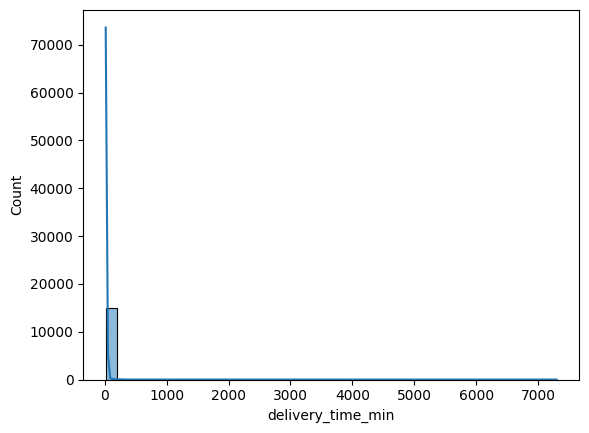

In [28]:
# distribution of delivery time

sns.histplot(df['delivery_time_min'], bins=40, kde=True)


<Axes: xlabel='delivery_time_min'>

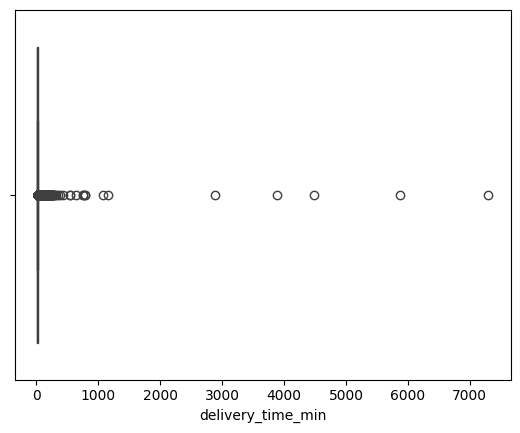

In [29]:
# Checking for outliers

sns.boxplot(x=df['delivery_time_min'])

In [30]:
# __Insights__

# total 557 orders out of 15000 delivered after 31 minutes
# only 3.71% orders are late delivered
# there are some extreme outliers in delivery time
# overall , 95th Percentile on Order Delivery time is less than 31 minutes